## 1. Setup and Paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1. Data").exists() and (candidate / "2. Code").exists():
            return candidate
    raise FileNotFoundError("Could not find the CAPSTONE project root.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
CITY_SPECIFIC_OUTPUT_DIR = DATA_DIR / "Outputs" / "city_specific"
ML_OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models"
ARCHIVE_OUTPUT_DIR = DATA_DIR / "Outputs" / "archive_outdated_20260607"
ML_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model-ready folder:", MODEL_READY_DIR)
print("ML output folder:", ML_OUTPUT_DIR)

Project root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Model-ready folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\model_ready
ML output folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models


This setup cell finds the project root automatically, then points to the shared `1. Data` folders. The tutor-facing outputs are written to `1. Data/Outputs/ml_models`.

## 2. Supervised Models: Comparison Table

In [2]:
baseline_path = CITY_SPECIFIC_OUTPUT_DIR / "city_specific_baseline_results.csv"
expanded_results_path = ML_OUTPUT_DIR / "expanded_city_model_results.csv"
fallback_results_path = ARCHIVE_OUTPUT_DIR / "city_specific_ml_results.csv"
original_comparison_path = ARCHIVE_OUTPUT_DIR / "city_specific_vs_original_comparison.csv"

if not baseline_path.exists():
    raise FileNotFoundError(f"Missing baseline results: {baseline_path}")

if expanded_results_path.exists():
    supervised_path = expanded_results_path
elif fallback_results_path.exists():
    supervised_path = fallback_results_path
else:
    raise FileNotFoundError("Missing supervised model results CSV in active ml_models or archive output folder.")

baseline_df = pd.read_csv(baseline_path)
supervised_df = pd.read_csv(supervised_path)

baseline_table = baseline_df.assign(model_family="Baseline")[[
    "city", "model_family", "model", "rmse_eur", "mae_eur", "r2"
]]

supervised_table = supervised_df.assign(model_family="Supervised")[[
    "city", "model_family", "model", "rmse_eur", "mae_eur", "r2"
]]

comparison_table = pd.concat([baseline_table, supervised_table], ignore_index=True)
comparison_table["rank_within_city"] = comparison_table.groupby("city")["rmse_eur"].rank(method="dense")
comparison_table["is_best_supervised"] = False

best_supervised_idx = (
    comparison_table[comparison_table["model_family"] == "Supervised"]
    .sort_values(["city", "rmse_eur"])
    .groupby("city")
    .head(1)
    .index
)
comparison_table.loc[best_supervised_idx, "is_best_supervised"] = True

family_order = {"Baseline": 0, "Supervised": 1}
comparison_table["family_order"] = comparison_table["model_family"].map(family_order)
comparison_table = (
    comparison_table
    .sort_values(["city", "family_order", "rmse_eur"])
    .drop(columns="family_order")
    .reset_index(drop=True)
)

comparison_out = ML_OUTPUT_DIR / "tutor_supervised_model_comparison.csv"
comparison_table.to_csv(comparison_out, index=False)

best_supervised = comparison_table[comparison_table["is_best_supervised"]].copy()
best_out = ML_OUTPUT_DIR / "tutor_supervised_best_models.csv"
best_supervised.to_csv(best_out, index=False)

print(f"Loaded supervised results from: {supervised_path.name}")
print(f"Saved comparison table to: {comparison_out}")
print(f"Saved best-model summary to: {best_out}")

display(comparison_table.style.format({
    "rmse_eur": "{:.2f}",
    "mae_eur": "{:.2f}",
    "r2": "{:.4f}",
    "rank_within_city": "{:.0f}",
}))

print("Best supervised model by city:")
display(best_supervised[["city", "model", "rmse_eur", "mae_eur", "r2"]].style.format({
    "rmse_eur": "{:.2f}",
    "mae_eur": "{:.2f}",
    "r2": "{:.4f}",
}))

if original_comparison_path.exists():
    original_comparison = pd.read_csv(original_comparison_path)
    print("City-specific XGBoost compared with the original combined-data XGBoost:")
    display(original_comparison.style.format({
        "rmse_eur": "{:.2f}",
        "mae_eur": "{:.2f}",
        "r2": "{:.4f}",
        "original_combined_rmse_eur": "{:.2f}",
        "original_combined_mae_eur": "{:.2f}",
        "original_combined_r2": "{:.4f}",
        "rmse_change_vs_original": "{:.2f}",
        "mae_change_vs_original": "{:.2f}",
        "r2_change_vs_original": "{:.4f}",
    }))

Loaded supervised results from: expanded_city_model_results.csv
Saved comparison table to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_model_comparison.csv
Saved best-model summary to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_best_models.csv


,city,model_family,model,rmse_eur,mae_eur,r2,rank_within_city,is_best_supervised
0,Madrid,Baseline,Neighbourhood + room + size median baseline,44.73,31.12,0.4768,10,False
1,Madrid,Baseline,Neighbourhood + room median baseline,50.04,35.94,0.3451,11,False
2,Madrid,Baseline,Room type median baseline,53.25,38.63,0.2584,12,False
3,Madrid,Baseline,City median baseline,62.45,48.79,-0.0201,13,False
4,Madrid,Supervised,XGBoost Tuned,30.59,20.41,0.7624,1,True
5,Madrid,Supervised,LightGBM,31.75,21.28,0.7439,2,False
6,Madrid,Supervised,Extra Trees,32.41,21.39,0.7331,3,False
7,Madrid,Supervised,Random Forest,33.04,21.97,0.7227,4,False
8,Madrid,Supervised,CatBoost,33.08,22.27,0.7220,5,False
9,Madrid,Supervised,Random Forest Tuned,33.24,22.15,0.7193,6,False


Best supervised model by city:


,city,model,rmse_eur,mae_eur,r2
4,Madrid,XGBoost Tuned,30.59,20.41,0.7624
17,Tokyo,XGBoost Tuned,28.55,18.95,0.7372


City-specific XGBoost compared with the original combined-data XGBoost:


,city,model,rmse_eur,mae_eur,r2,original_reference_model,original_combined_rmse_eur,original_combined_mae_eur,original_combined_r2,rmse_change_vs_original,mae_change_vs_original,r2_change_vs_original
0,Madrid,XGBoost,33.34,22.62,0.7177,XGBoost,36.88,25.87,0.5993,-3.54,-3.25,0.1184
1,Tokyo,XGBoost,31.97,22.16,0.6705,XGBoost,36.88,25.87,0.5993,-4.91,-3.71,0.0712


This table compares the simple baselines against all available supervised models using the same three metrics: RMSE, MAE and R2. Lower RMSE/MAE is better, while higher R2 is better. The best supervised model for each city is flagged in the `is_best_supervised` column.

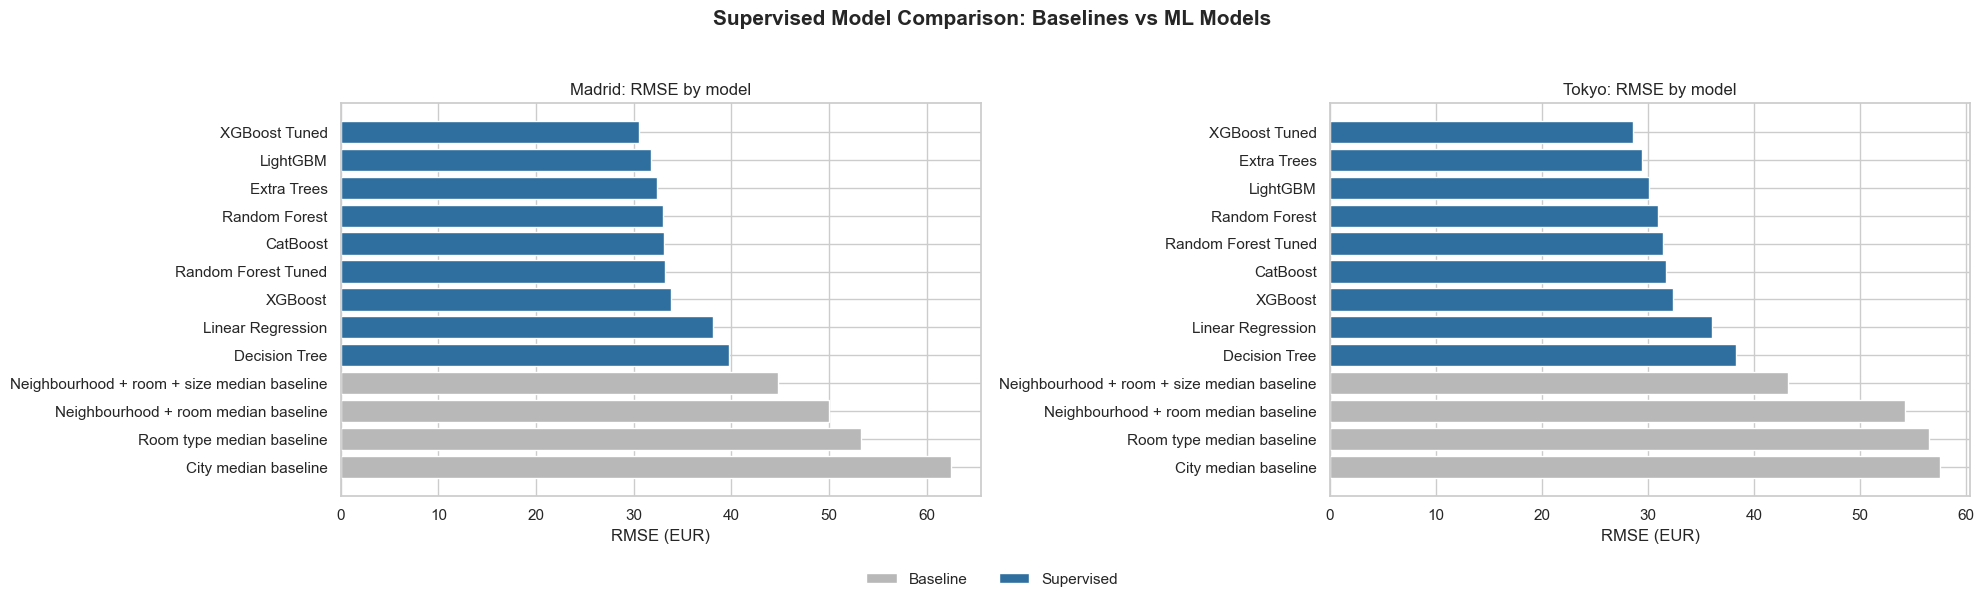

Saved plot to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_rmse_comparison.png


In [3]:
plot_df = comparison_table.copy()
city_order = sorted(plot_df["city"].unique())

fig, axes = plt.subplots(1, len(city_order), figsize=(10 * len(city_order), 6), sharex=False)
if len(city_order) == 1:
    axes = [axes]

colors = {"Baseline": "#B8B8B8", "Supervised": "#2F6F9F"}

for ax, city in zip(axes, city_order):
    city_df = plot_df[plot_df["city"] == city].sort_values("rmse_eur", ascending=True)
    ax.barh(city_df["model"], city_df["rmse_eur"], color=[colors[x] for x in city_df["model_family"]])
    ax.set_title(f"{city}: RMSE by model")
    ax.set_xlabel("RMSE (EUR)")
    ax.invert_yaxis()

from matplotlib.patches import Patch
legend_items = [Patch(facecolor=color, label=label) for label, color in colors.items()]
fig.legend(handles=legend_items, loc="lower center", ncol=2, frameon=False)
plt.suptitle("Supervised Model Comparison: Baselines vs ML Models", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

plot_out = ML_OUTPUT_DIR / "tutor_supervised_rmse_comparison.png"
plt.savefig(plot_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {plot_out}")

The chart makes the comparison easier to present. It shows whether the supervised models improve on the baseline approaches and which model performs best in each city.

## 3. Unsupervised Models: KMeans Market Segmentation

In [4]:
CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

CLUSTER_FEATURES = [
    "price_eur",
    "accommodates",
    "bedrooms",
    "amenities_count",
    "distance_to_center_km",
    "availability_365",
    "review_scores_rating",
    "host_is_superhost",
    "minimum_nights_capped",
]

N_CLUSTERS = 4
SEGMENT_LABELS = ["Value", "Standard", "Premium", "Luxury"]

all_scores = []
all_profiles = []
all_segments = []
pca_samples = []

for city, path in CITY_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing model-ready data for {city}: {path}")

    df = pd.read_csv(path)
    available_features = [feature for feature in CLUSTER_FEATURES if feature in df.columns]
    if len(available_features) < 4:
        raise ValueError(f"Not enough clustering features available for {city}.")

    working = df[available_features].replace([np.inf, -np.inf], np.nan).dropna().copy()
    working.insert(0, "model_ready_row", working.index)

    X = working[available_features]
    X_scaled = StandardScaler().fit_transform(X)

    for k in range(2, 9):
        kmeans_check = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels_check = kmeans_check.fit_predict(X_scaled)
        all_scores.append({
            "city": city,
            "k": k,
            "inertia": kmeans_check.inertia_,
            "silhouette_score": silhouette_score(
                X_scaled,
                labels_check,
                sample_size=min(5000, len(X_scaled)),
                random_state=RANDOM_STATE,
            ),
            "rows_used": len(working),
            "features_used": ", ".join(available_features),
        })

    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=30)
    working["cluster_id"] = kmeans.fit_predict(X_scaled)

    profile = (
        working
        .groupby("cluster_id")
        .agg(
            listings=("price_eur", "size"),
            median_price_eur=("price_eur", "median"),
            mean_price_eur=("price_eur", "mean"),
            median_accommodates=("accommodates", "median"),
            median_bedrooms=("bedrooms", "median"),
            median_amenities=("amenities_count", "median"),
            median_distance_to_center_km=("distance_to_center_km", "median"),
            median_availability_365=("availability_365", "median"),
            mean_review_score=("review_scores_rating", "mean"),
            superhost_rate=("host_is_superhost", "mean"),
            median_minimum_nights=("minimum_nights_capped", "median"),
        )
        .reset_index()
    )
    profile = profile.sort_values("median_price_eur").reset_index(drop=True)
    profile["segment"] = SEGMENT_LABELS[:len(profile)]
    profile["city"] = city

    cluster_to_segment = dict(zip(profile["cluster_id"], profile["segment"]))
    working["segment"] = working["cluster_id"].map(cluster_to_segment)
    working["city"] = city

    profile = profile[["city", "segment", "cluster_id", "listings", "median_price_eur", "mean_price_eur",
                       "median_accommodates", "median_bedrooms", "median_amenities",
                       "median_distance_to_center_km", "median_availability_365",
                       "mean_review_score", "superhost_rate", "median_minimum_nights"]]
    numeric_cols = profile.select_dtypes(include="number").columns
    profile[numeric_cols] = profile[numeric_cols].round(2)

    all_profiles.append(profile)
    all_segments.append(working[["city", "model_ready_row", "cluster_id", "segment", *available_features]])

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X_scaled)
    sample = working.sample(min(2500, len(working)), random_state=RANDOM_STATE).copy()
    sample_coords = pd.DataFrame(coords, index=working.index, columns=["pc1", "pc2"]).loc[sample.index]
    sample = sample.join(sample_coords)
    pca_samples.append(sample[["city", "segment", "pc1", "pc2", "price_eur"]])

scores_df = pd.DataFrame(all_scores)
profiles_df = pd.concat(all_profiles, ignore_index=True)
segments_df = pd.concat(all_segments, ignore_index=True)
pca_sample_df = pd.concat(pca_samples, ignore_index=True)

scores_out = ML_OUTPUT_DIR / "tutor_unsupervised_kmeans_scores.csv"
profiles_out = ML_OUTPUT_DIR / "tutor_unsupervised_cluster_profiles.csv"
segments_out = ML_OUTPUT_DIR / "tutor_unsupervised_listing_segments.csv"

scores_df.to_csv(scores_out, index=False)
profiles_df.to_csv(profiles_out, index=False)
segments_df.to_csv(segments_out, index=False)

print(f"Saved KMeans scores to: {scores_out}")
print(f"Saved cluster profiles to: {profiles_out}")
print(f"Saved listing segment assignments to: {segments_out}")

print("KMeans validation scores:")
display(scores_df.style.format({"inertia": "{:.2f}", "silhouette_score": "{:.4f}"}))

print("Cluster profile summary:")
display(profiles_df.style.format({
    "median_price_eur": "{:.2f}",
    "mean_price_eur": "{:.2f}",
    "median_accommodates": "{:.1f}",
    "median_bedrooms": "{:.1f}",
    "median_amenities": "{:.1f}",
    "median_distance_to_center_km": "{:.2f}",
    "median_availability_365": "{:.0f}",
    "mean_review_score": "{:.2f}",
    "superhost_rate": "{:.2%}",
    "median_minimum_nights": "{:.0f}",
}))

  File "C:\Users\georg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\georg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\georg\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\georg\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\georg\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Saved KMeans scores to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_unsupervised_kmeans_scores.csv
Saved cluster profiles to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_unsupervised_cluster_profiles.csv
Saved listing segment assignments to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_unsupervised_listing_segments.csv
KMeans validation scores:


,city,k,inertia,silhouette_score,rows_used,features_used
0,Madrid,2,109811.73,0.1825,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
1,Madrid,3,96673.56,0.1746,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
2,Madrid,4,86688.43,0.1903,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
3,Madrid,5,80359.23,0.1683,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
4,Madrid,6,73598.54,0.1740,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
5,Madrid,7,68917.96,0.1744,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
6,Madrid,8,65962.85,0.1616,14446,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
7,Tokyo,2,142881.28,0.2222,19158,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
8,Tokyo,3,125115.47,0.2566,19158,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"
9,Tokyo,4,109225.24,0.2141,19158,"price_eur, accommodates, bedrooms, amenities_count, distance_to_center_km, availability_365, review_scores_rating, host_is_superhost, minimum_nights_capped"


Cluster profile summary:


,city,segment,cluster_id,listings,median_price_eur,mean_price_eur,median_accommodates,median_bedrooms,median_amenities,median_distance_to_center_km,median_availability_365,mean_review_score,superhost_rate,median_minimum_nights
0,Madrid,Value,2,1674,87.00,97.82,2.0,1.0,28.0,1.99,238,4.56,25.00%,30
1,Madrid,Standard,0,6749,93.00,95.60,2.0,1.0,26.0,2.05,246,4.53,0.00%,1
2,Madrid,Premium,3,3304,99.00,103.87,2.0,1.0,34.0,2.06,177,4.84,100.00%,2
3,Madrid,Luxury,1,2719,187.00,190.85,6.0,2.0,32.0,1.21,244,4.65,23.00%,1
4,Tokyo,Value,0,1351,67.77,79.83,3.0,1.0,30.0,6.53,161,4.67,26.00%,30
5,Tokyo,Standard,1,7859,83.68,91.20,3.0,1.0,30.0,6.53,147,4.61,0.00%,1
6,Tokyo,Premium,3,6703,97.33,104.45,3.0,1.0,33.0,6.68,161,4.84,100.00%,2
7,Tokyo,Luxury,2,3245,181.18,180.89,8.0,3.0,38.0,7.44,203,4.82,58.00%,2


This is the unsupervised modelling section. KMeans does not use the target as a prediction task; it groups listings into market segments based on price, capacity, location, availability, rating and host/listing attributes. The resulting segment labels are ordered by median price so they are easy to explain: Value, Standard, Premium and Luxury.

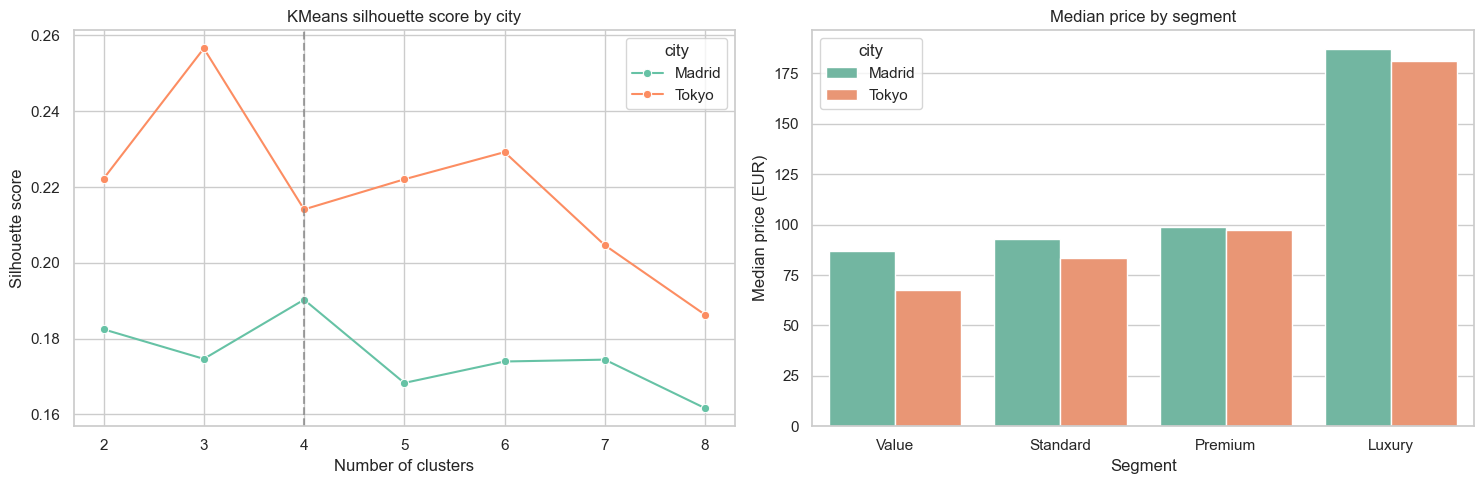

Saved segment profile plot to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_unsupervised_segment_profiles.png


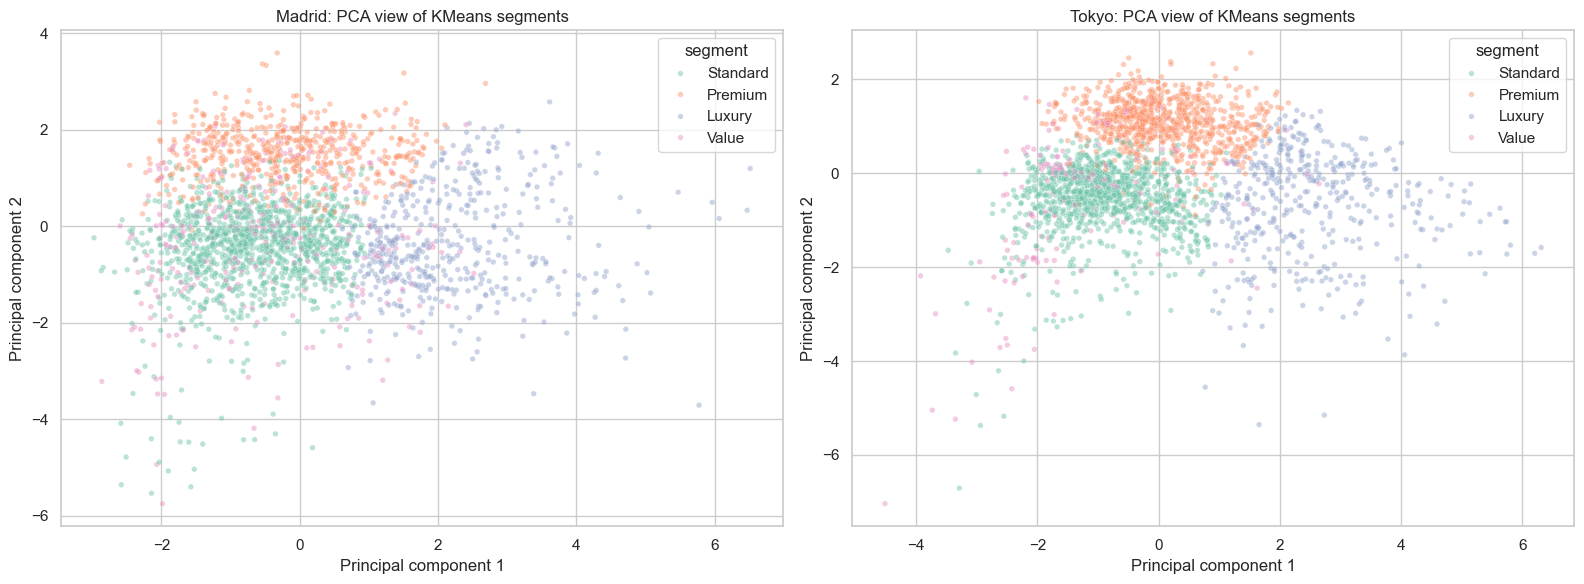

Saved PCA segment plot to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_unsupervised_pca_segments.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=scores_df, x="k", y="silhouette_score", hue="city", marker="o", ax=axes[0])
axes[0].axvline(N_CLUSTERS, color="grey", linestyle="--", alpha=0.7)
axes[0].set_title("KMeans silhouette score by city")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")

sns.barplot(data=profiles_df, x="segment", y="median_price_eur", hue="city", ax=axes[1])
axes[1].set_title("Median price by segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Median price (EUR)")

plt.tight_layout()
profile_plot_out = ML_OUTPUT_DIR / "tutor_unsupervised_segment_profiles.png"
plt.savefig(profile_plot_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved segment profile plot to: {profile_plot_out}")

fig, axes = plt.subplots(1, len(pca_sample_df["city"].unique()), figsize=(8 * pca_sample_df["city"].nunique(), 6))
if pca_sample_df["city"].nunique() == 1:
    axes = [axes]

for ax, city in zip(axes, sorted(pca_sample_df["city"].unique())):
    city_sample = pca_sample_df[pca_sample_df["city"] == city]
    sns.scatterplot(
        data=city_sample,
        x="pc1",
        y="pc2",
        hue="segment",
        s=16,
        alpha=0.45,
        ax=ax,
    )
    ax.set_title(f"{city}: PCA view of KMeans segments")
    ax.set_xlabel("Principal component 1")
    ax.set_ylabel("Principal component 2")

plt.tight_layout()
pca_plot_out = ML_OUTPUT_DIR / "tutor_unsupervised_pca_segments.png"
plt.savefig(pca_plot_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved PCA segment plot to: {pca_plot_out}")

The first plot supports the choice of cluster count and shows segment price levels, while the PCA plot gives a two-dimensional view of how listings separate into market groups.

## 4. Supervised vs Unsupervised: How to Read Them Together

The supervised and unsupervised outputs should be shown together, but not as if they share the same accuracy metric. Supervised models predict a known target price and are evaluated with RMSE, MAE and R2. Unsupervised KMeans does not predict price; it segments listings into market groups and is evaluated with clustering diagnostics such as silhouette score, plus interpretability of the segment profiles.

In [6]:
supervised_best = pd.read_csv(ML_OUTPUT_DIR / "tutor_supervised_best_models.csv")
cluster_profiles = pd.read_csv(ML_OUTPUT_DIR / "tutor_unsupervised_cluster_profiles.csv")
cluster_scores = pd.read_csv(ML_OUTPUT_DIR / "tutor_unsupervised_kmeans_scores.csv")

k4_scores = cluster_scores[cluster_scores["k"] == N_CLUSTERS][[
    "city", "k", "silhouette_score", "rows_used"
]].copy()

model_family_overview = pd.DataFrame([
    {
        "model_family": "Supervised price prediction",
        "uses_target_price": "Yes",
        "main_question": "Can we predict nightly price accurately?",
        "example_models": "Linear Regression, Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost",
        "main_outputs": "Predicted nightly price and model error metrics",
        "evaluation_metrics": "RMSE, MAE, R2",
        "how_to_read": "Lower RMSE/MAE and higher R2 indicate better price prediction.",
    },
    {
        "model_family": "Unsupervised segmentation",
        "uses_target_price": "No prediction target",
        "main_question": "What natural market segments exist in the listings?",
        "example_models": "KMeans clustering with k=4",
        "main_outputs": "Listing segments: Value, Standard, Premium and Luxury",
        "evaluation_metrics": "Silhouette score, inertia and segment interpretability",
        "how_to_read": "Segments are useful when they are distinct, explainable and commercially meaningful.",
    },
])

overview_out = ML_OUTPUT_DIR / "tutor_supervised_vs_unsupervised_overview.csv"
model_family_overview.to_csv(overview_out, index=False)

city_rows = []
for city in sorted(supervised_best["city"].unique()):
    best = supervised_best[supervised_best["city"] == city].iloc[0]
    score = k4_scores[k4_scores["city"] == city].iloc[0]
    profile = cluster_profiles[cluster_profiles["city"] == city].copy()
    city_rows.append({
        "city": city,
        "best_supervised_model": best["model"],
        "supervised_rmse_eur": best["rmse_eur"],
        "supervised_mae_eur": best["mae_eur"],
        "supervised_r2": best["r2"],
        "unsupervised_model": f"KMeans k={int(score['k'])}",
        "unsupervised_silhouette_score": score["silhouette_score"],
        "segments_found": ", ".join(profile["segment"].tolist()),
        "segment_median_price_range_eur": f"{profile['median_price_eur'].min():.2f} to {profile['median_price_eur'].max():.2f}",
        "clustered_rows": int(score["rows_used"]),
    })

city_comparison = pd.DataFrame(city_rows)
city_comparison_out = ML_OUTPUT_DIR / "tutor_supervised_vs_unsupervised_city_summary.csv"
city_comparison.to_csv(city_comparison_out, index=False)

print(f"Saved overview table to: {overview_out}")
print(f"Saved city summary to: {city_comparison_out}")

display(model_family_overview)
display(city_comparison.style.format({
    "supervised_rmse_eur": "{:.2f}",
    "supervised_mae_eur": "{:.2f}",
    "supervised_r2": "{:.4f}",
    "unsupervised_silhouette_score": "{:.4f}",
}))

Saved overview table to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_vs_unsupervised_overview.csv
Saved city summary to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_vs_unsupervised_city_summary.csv


,model_family,uses_target_price,main_question,example_models,main_outputs,evaluation_metrics,how_to_read
0,Supervised price prediction,Yes,Can we predict nightly price accurately?,"Linear Regression, Decision Tree, Random Fores...",Predicted nightly price and model error metrics,"RMSE, MAE, R2",Lower RMSE/MAE and higher R2 indicate better p...
1,Unsupervised segmentation,No prediction target,What natural market segments exist in the list...,KMeans clustering with k=4,"Listing segments: Value, Standard, Premium and...","Silhouette score, inertia and segment interpre...","Segments are useful when they are distinct, ex..."


,city,best_supervised_model,supervised_rmse_eur,supervised_mae_eur,supervised_r2,unsupervised_model,unsupervised_silhouette_score,segments_found,segment_median_price_range_eur,clustered_rows
0,Madrid,XGBoost Tuned,30.59,20.41,0.7624,KMeans k=4,0.1903,"Value, Standard, Premium, Luxury",87.00 to 187.00,14446
1,Tokyo,XGBoost Tuned,28.55,18.95,0.7372,KMeans k=4,0.2141,"Value, Standard, Premium, Luxury",67.77 to 181.18,19158


The first table explains the conceptual difference between the two modelling families. The city summary then places the best supervised price model next to the KMeans segmentation result.

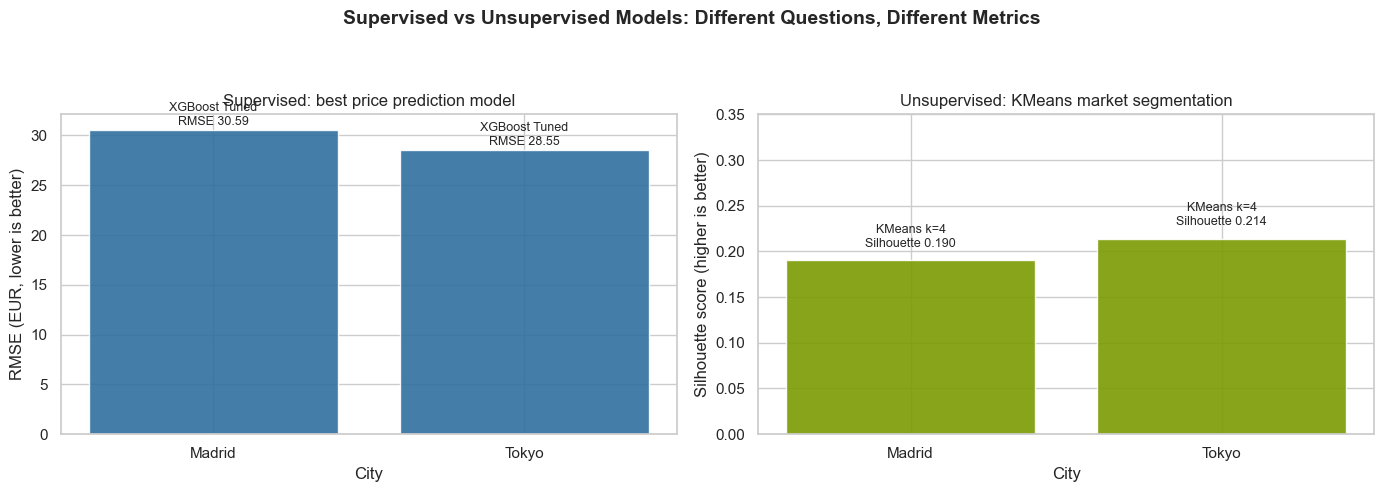

Saved metric summary plot to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_vs_unsupervised_metric_summary.png


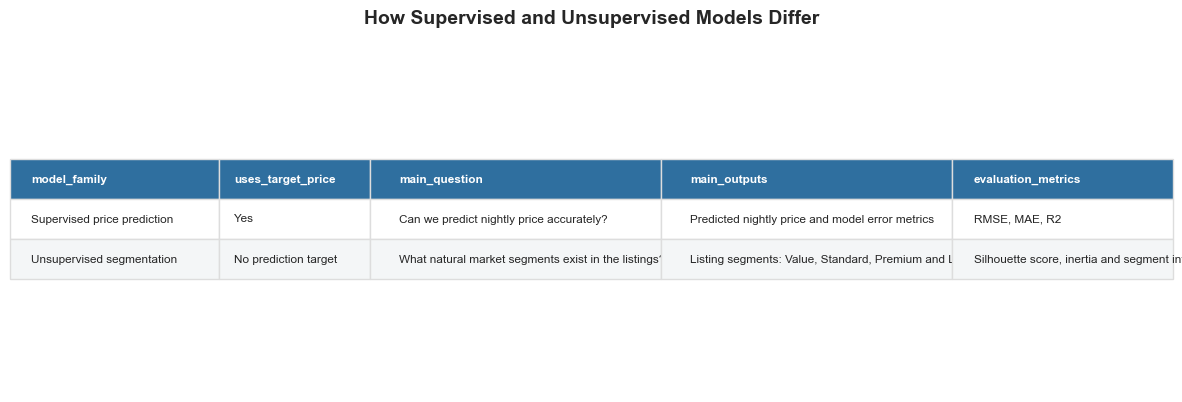

Saved overview plot to: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\tutor_supervised_vs_unsupervised_overview.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

supervised_plot = supervised_best.sort_values("city")
axes[0].bar(supervised_plot["city"], supervised_plot["rmse_eur"], color="#2F6F9F", alpha=0.9)
axes[0].set_title("Supervised: best price prediction model")
axes[0].set_ylabel("RMSE (EUR, lower is better)")
axes[0].set_xlabel("City")
for idx, row in supervised_plot.reset_index(drop=True).iterrows():
    axes[0].text(idx, row["rmse_eur"] + 0.5, f"{row['model']}\nRMSE {row['rmse_eur']:.2f}", ha="center", fontsize=9)

unsupervised_plot = k4_scores.sort_values("city")
axes[1].bar(unsupervised_plot["city"], unsupervised_plot["silhouette_score"], color="#7A9A01", alpha=0.9)
axes[1].set_title("Unsupervised: KMeans market segmentation")
axes[1].set_ylabel("Silhouette score (higher is better)")
axes[1].set_xlabel("City")
axes[1].set_ylim(0, max(0.35, unsupervised_plot["silhouette_score"].max() + 0.08))
for idx, row in unsupervised_plot.reset_index(drop=True).iterrows():
    axes[1].text(idx, row["silhouette_score"] + 0.015, f"KMeans k={int(row['k'])}\nSilhouette {row['silhouette_score']:.3f}", ha="center", fontsize=9)

plt.suptitle("Supervised vs Unsupervised Models: Different Questions, Different Metrics", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
metric_plot_out = ML_OUTPUT_DIR / "tutor_supervised_vs_unsupervised_metric_summary.png"
plt.savefig(metric_plot_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved metric summary plot to: {metric_plot_out}")

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.axis("off")
plot_table = model_family_overview[[
    "model_family", "uses_target_price", "main_question", "main_outputs", "evaluation_metrics"
]].copy()

table = ax.table(
    cellText=plot_table.values,
    colLabels=plot_table.columns,
    loc="center",
    cellLoc="left",
    colLoc="left",
    colWidths=[0.18, 0.13, 0.25, 0.25, 0.19],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 2.4)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#DDDDDD")
    if row == 0:
        cell.set_facecolor("#2F6F9F")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F4F6F7")
    else:
        cell.set_facecolor("#FFFFFF")

plt.title("How Supervised and Unsupervised Models Differ", fontsize=14, fontweight="bold", pad=16)
overview_plot_out = ML_OUTPUT_DIR / "tutor_supervised_vs_unsupervised_overview.png"
plt.savefig(overview_plot_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved overview plot to: {overview_plot_out}")

These two visuals are intended for the tutor discussion. The metric summary puts the best supervised result and the unsupervised segmentation result on one page, while the overview plot explains why the metrics cannot be directly ranked against each other.